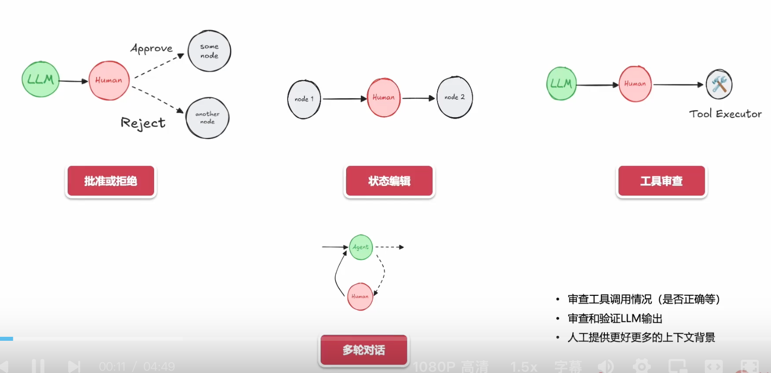

用人工审核ai的处理流程,包含下面的场景:
- 基本运用：等待用户输入
- 基本运用：审查工具调用
- 基本使用：编辑图的状态

## 一.等待用户输入
### 01.在图中引入用户干预
> human_feedback 节点中引入了一个interrupt,必须在调用graph的时候传入command指令,图才能继续运行

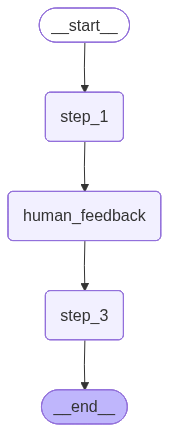

In [52]:
from langchain_classic.schema.runnable import retry
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph,START,END
from langgraph.types import Command,interrupt
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image,display
from pydantic import BaseModel,Field

class State(BaseModel):
    input:str = Field(default="")
    user_feedback:str = Field(default="")

def step_1(state:State):
    print("-----step_1-------")
    pass

def human_feedback(state:State):
    print("-----human_feedback-------")
    feedback = interrupt("plesase provide feedback:")
    return {
        "user_feedback":feedback
    }


def step_3(state:State):
    print("-----step_3-------")
    pass

graph_builder = StateGraph(State)
graph_builder.add_node("step_1",step_1)
graph_builder.add_node("human_feedback",human_feedback)
graph_builder.add_node("step_3",step_3)

graph_builder.add_edge(START,"step_1")
graph_builder.add_edge("step_1","human_feedback")
graph_builder.add_edge("human_feedback","step_3")
graph_builder.add_edge("step_3",END)

memory =  MemorySaver()

graph =  graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
# input
initial_input = {
    "messages":[
        {
            "role":"user",
            "content":"hello"
        }
    ]
}

config = {
    "configurable":{
        "thread_id":"1"
    }
}

res = graph.stream(input=initial_input,config=config,stream_mode="updates")

# 执行会被打断,因为human_feedback需要用户输入
for event in res:
    print(event)
    print()

-----step_1-------
{'step_1': None}

-----human_feedback-------
{'__interrupt__': (Interrupt(value='plesase provide feedback:', id='ca65896a08de6c90431560e6d261aa3a'),)}



In [54]:
# 需要注入用户的输入,图才能继续执行

for event in graph.stream(Command(resume="go to step 3"),config=config,stream_mode="updates"):
    print(event)
    print()


-----human_feedback-------
{'human_feedback': {'user_feedback': 'go to step 3'}}

-----step_3-------
{'step_3': None}



### 02.在一个agent中引入人工干预

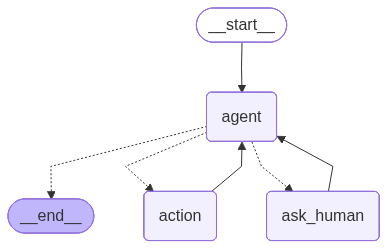

In [55]:
from langgraph.graph import MessagesState,START

# 我们将设置一个真实工具,一个假工具
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

@tool
def search(query:str):
    '''
    调用此函数来浏览网络
    :param query:
    :return:
    '''

    return f"我查询了:{query},结果:北京天气晴朗,温度25度"

tools = [search]

tool_node = ToolNode(tools)

# 设置模型
from model_factory import MiniMax_Model
import os

# 我们上面有一个工具,但是我们还要定一个工具来模拟询问人类
# 由于 bing_tools可以接受工具方法也可以接受工具类定义,我们将AskHuman定义为一个工具
class AskHuman(BaseModel):
    question:str

model = MiniMax_Model.bind_tools(tools + [AskHuman])


# 定义条件边
def shoul_continue(state:MessagesState):
    messges = state["messages"]
    last_message = messges[-1]

    # 如果没有调用函数则结束
    if not last_message.tool_calls:
        return END

    # 如果工具调用时人类询问,我们应该返回节点
    # 你可以在这里添加逻辑,让系统知道需要人类输入内容,例如发送slack消息
    elif last_message.tool_calls[0]["name"] == "AskHuman":
        return "ask_human"
    else:
        return "action"

def call_model(state:MessagesState):
    messages = state["messages"]
    response = model.invoke(messages)
    return {
        "messages":[response]
    }

def ask_human(state:MessagesState):
    # 取最后一条消息的tool id
    tool_call_id = state["messages"][-1].tool_calls[0]["id"]
    # 验证tool_call 参数对不对
    ask = AskHuman.model_validate(state["messages"][-1].tool_calls[0]["args"])
    # 使用interrupt中断workflow
    location = interrupt(ask.question)
    tool_message = [
        ToolMessage(
            content=location,
            tool_call_id=tool_call_id
        )
    ]
    return {
        "messages":tool_message
    }


workflow_builder = StateGraph(MessagesState)

workflow_builder.add_node("agent",call_model)
workflow_builder.add_node("action",tool_node)
workflow_builder.add_node("ask_human",ask_human)

workflow_builder.add_edge(START,"agent")

workflow_builder.add_conditional_edges(
    "agent",
    shoul_continue,
    {
        "action":"action",
        "ask_human":"ask_human",
        "__end__":END
    }
)

workflow_builder.add_edge("action","agent")
workflow_builder.add_edge("ask_human","agent")
workflow_builder.add_edge("agent",END)

app = workflow_builder.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))



In [56]:
config = {
    "configurable":{
        "thread_id":"1"
    }
}

input = {
    "messages":[
        {
            "role":"user",
            "content":"询问用户住在哪里,让后查询那里的天气"
        }
    ]
}

for event in app.stream(input,config=config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

询问用户住在哪里,让后查询那里的天气
================================== Ai Message ==================================



好的！请问您住在哪里呢？告诉我城市名称后，我就可以帮您查询当地的天气啦！


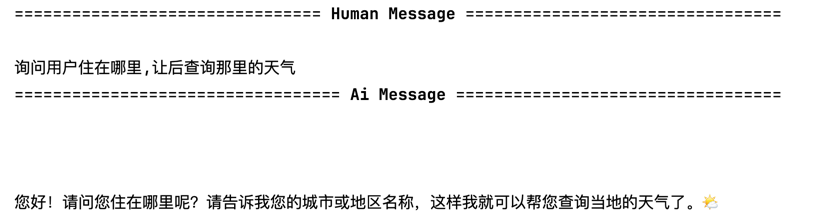

可以看到之类workflow暂停了,agent提示需要我们来补充信息,接下来我们通过注入command提供地址,让workflow继续执行.

In [57]:
for event in app.stream(Command(resume="北京"),config=config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================



好的！请问您住在哪里呢？告诉我城市名称后，我就可以帮您查询当地的天气啦！


## 2.审查工具调用

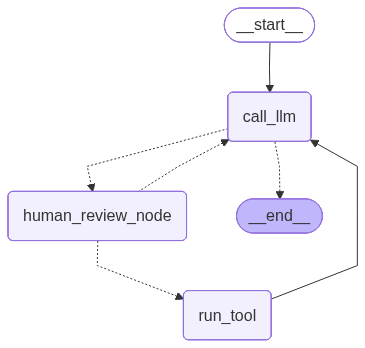

In [58]:
from typing import Literal
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.types import Command,interrupt
from langchain_core.tools import tool
from langchain_core.messages import AIMessage
from IPython.display import Image,display
from model_factory import MiniMax_Model

@tool
def weather_search(city:str):
    '''
    搜索天气
    :param city:
    :return:
    '''
    print("-"*20)
    print(f"正在查询:{city}")
    return f"{city}天气晴朗,温度25度"


class State(MessagesState):
    '''
    简单状态
    '''

model = MiniMax_Model.bind_tools([weather_search])

def call_llm(state:State):
    return {
        "messages":[model.invoke(state["messages"])]
    }


def human_review_node(state:State) -> Command[Literal["call_llm","run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    # 这是我们将通过command(resume=<human resume>)提供的值
    human_review = interrupt({
        "question":"这是正确的吗?",
        "tool_call":tool_call,
    })

    review_action = human_review["action"]
    review_data = human_review["data"]

    # 如果批准,调用工具
    if review_action == "approve":
        return Command(goto="run_tool")
    # 更新ai消息并调用工具
    elif review_action == "update":
        updated_message = {
            "role":"ai",
            "content":last_message.content,
            "tool_calls":[
                {
                    "id":tool_call["id"],
                    "name":tool_call["name"],
                    # 人类提供的更新
                    "args":review_data,
                }
            ],
            # 这很重要, 这需要和你替换的消息相同,不然它会显示成为一个单独的消息
            "id":last_message.id
        }
        return Command(goto="run_tool",update={"messages":[updated_message]})

    elif review_action == "feedback":
        # 注意我们将反馈消息添加为 ToolMessage
        # 以保持消息历史的正确顺序(工具调用的AI消息 后面要跟 工具调用消息)
        tool_message = {
            "role":"tool",
            # 这是我们的自然语言反馈
            "content":review_data,
            "name":tool_call["name"],
            "tool_call_id":tool_call["id"],
        }
        return Command(goto="call_llm",update={"messages":[tool_message]})

def run_tool(state:State):
    new_messages = []
    tools = {"weather_search":weather_search}
    tool_calls = state["messages"][-1].tool_calls

    for tool_call in tool_calls:
        # 获取工具名字
        tool = tools[tool_call["name"]]
        result = tool.invoke(tool_call["args"])

        new_messages.append({
            "role":"tool",
            "content":result,
            "name":tool_call["name"],
            "tool_call_id":tool_call["id"],
        })
    return {
        "messages":new_messages
    }


def route_after_llm(state:State) -> Literal[END,"human_review_node"]:
    if len(state["messages"][-1].tool_calls) == 0:
        return END
    else:
        return "human_review_node"


graph_builder = StateGraph(State)
graph_builder.add_node(call_llm)
graph_builder.add_node(run_tool)
graph_builder.add_node(human_review_node)
graph_builder.add_edge(START,"call_llm")
graph_builder.add_conditional_edges("call_llm",route_after_llm)
graph_builder.add_edge("run_tool","call_llm")

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

当不涉及工具调用的时候,不会出发人工审核

In [59]:
# 当不涉及工具调用的时候,不会出发人工审核
initial_input = {
    "messages":[
        {
            "role":"user",
            "content":"hello"
        }
    ]
}

config = {
    "configurable":{
        "thread_id":"1"
    }
}

for event in graph.stream(initial_input,config=config,stream_mode="values"):
    event["messages"][-1].pretty_print()


================================ Human Message =================================

hello
================================== Ai Message ==================================



Hello! How can I help you today? Whether you need assistance with information, calculations, or anything else, feel free to ask!


一旦涉及到工具调用,就会出发人工介入

In [62]:
# 当涉及工具调用的时候,会触发人工审核
initial_input = {
    "messages":[
        {
            "role":"user",
            "content":"北京的天气如何"
        }
    ]
}

config = {
    "configurable":{
        "thread_id":"2"
    }
}

for event in graph.stream(initial_input,config=config,stream_mode="updates"):
    print(event)

{'call_llm': {'messages': [AIMessage(content='\n\n\n', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'Pro/MiniMaxAI/MiniMax-M2.5', 'model_provider': 'openai'}, id='lc_run--019dcfcf-1b76-7f43-a845-e34e184e7c0f', tool_calls=[{'name': 'weather_search', 'args': {'city': '北京'}, 'id': '019dcfcf218c264e5161b6f1786d6705', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 14250, 'output_tokens': 1664, 'total_tokens': 15914, 'input_token_details': {'cache_read': 10752}, 'output_token_details': {'reasoning': 1581}})]}}
{'__interrupt__': (Interrupt(value={'question': '这是正确的吗?', 'tool_call': {'name': 'weather_search', 'args': {'city': '北京'}, 'id': '019dcfcf218c264e5161b6f1786d6705', 'type': 'tool_call'}}, id='4fe332aaa0c2abf11e75bc8c8bd82966'),)}


In [64]:
# 使用command进行人机交互 将之前用户输入的北京改成上海
for event in graph.stream(
    Command(resume={"action": "update", "data": {"city": "上海"}}),
    config=config,
    stream_mode="updates"
):
    print(event)


## 3.编辑图的状态